r# 프롬프트 엔지니어링과 생성 제어

프롬프트 엔지니어링(prompt engineering)은 LLM이 원하는 작업을 안정적으로 수행하도록 지시, 맥락, 입력 데이터, 출력 형식을 설계하는 방법이다. 같은 모델이라도 요청을 어떻게 구성하는지에 따라 답변의 정확성, 일관성, 형식 준수 수준이 달라진다. 프롬프트는 모델의 지식을 새로 학습시키는 파인튜닝과 달리, 실행 시점에 모델의 행동을 조정한다.

temperature는 다음 토큰 선택의 무작위성을 조절하는 값이며, top_p는 누적 확률 범위 안에서 후보 토큰을 고르는 값이다. 낮은 temperature는 재현 가능한 분류·추출에, 다소 높은 temperature는 초안·아이디어 생성에 유리할 수 있다. 그러나 값만 조절해서는 사실성을 보장할 수 없으므로, 검증 가능한 맥락과 출력 형식을 함께 제공해야 한다.

이번 실습은 Chat Completion의 메시지 구조와 대표 프롬프팅 기법을 읽고, 과제에 맞는 지시문을 설계하는 기준을 확인한다.


## Prompt HyperParameters

**ChatGPT LLM 설정**

https://blog.lukesalamone.com/posts/what-is-temperature/

1. **`temperature`**
    - **작동 방식**:  
      확률 분포를 **평탄화하거나 집중**시킨다.
      - 낮은 값 (`0.1` 등): 높은 확률의 토큰만 선택하게 하여 응답이 더 **결정적**(예측 가능)이다.
      - 높은 값 (`1.5` 등): 확률 분포를 평탄화하여 저확률 토큰도 선택할 가능성이 있어 응답이 더 **창의적**이고 다양한다.
    
    - **적용 범위**:
      - 문장이 단조롭거나 응답이 너무 예상 가능할 때 다양성을 부여.
      - 확률 분포를 조정하는 가장 기본적인 매개변수.
    
    - **비유**:
      - 음식을 만들 때 **조미료의 양을 조정**하는 것처럼, 다양성을 직접적으로 조절.

2. **`top-p`** (또는 **nucleus sampling**)
    - **작동 방식**:  
      확률 분포에서 누적 확률이 특정 값(`p`) 이하가 되는 상위 토큰들만 고려한다.  
      - 예: `top-p=0.9`라면, 전체 확률의 **90%를 차지하는 상위 토큰**들만 선택 후보로 유지.
      - 확률 분포의 **꼬리 부분**(즉, 낮은 확률 토큰)을 잘라내어 선택 가능성을 제한한다.
    
    - **적용 범위**:
      - 확률이 높은 후보군에 집중하면서도 너무 단조로운 응답을 방지.
      - 매우 드문(낮은 확률) 선택지를 배제.
    
    - **비유**:
      - 음식에서 **상위 재료 90%만 골라서 요리**하는 것처럼, 유의미한 선택만 남김.
3. **`최대 길이(Max Length)`**
    - 생성되는 토큰 수의 최대 길이를 제한한다.
    - 길이를 제한하여 응답 품질과 비용을 제어한다.
4. **`중지 시퀀스(Stop Sequences)`**
    - 특정 문자열에서 응답 생성을 중단한다.
    - 응답의 구조와 길이를 제어할 수 있다.
5. **`빈도 패널티(Frequency Penalty)`**
    - 특정 단어가 자주 반복되지 않도록 페널티를 적용한다.
    - 빈도 패널티가 높을수록 단어가 다시 나타날 가능성이 낮아짐.
    - 더 많이 나타나는 토큰에 더 높은 패널티를 부여함으로써 모델의 응답에서 단어의 반복을 줄임
6. **`존재 패널티(Presence Penalty)`**
    - 특정 단어가 한 번이라도 등장하면 페널티를 적용한다.
    - 빈도 패널티와 달리, 반복된 토큰에 대한 패널티를 적용하지만, 모든 반복된 토큰에 대해 패널티가 동일하다.
        - 두 번 나타나는 토큰과 열 번 나타나는 토큰이 같은 패널티를 받는다.
    - 모델이 응답에서 구절을 너무 자주 반복하는 것을 방지
    - 모델에게 다양하거나 창의적인 텍스트를 생성하도록 하고 싶다면 높은 존재 패널티를 사용


**temperature vs. top-p**

| **특징**           | **temperature**                        | **top-p**                            |
|---------------------|----------------------------------------|--------------------------------------|
| **작동 방식**       | 확률 분포를 평탄화하거나 집중          | 누적 확률 기준으로 후보 제한         |
| **결과 다양성**     | 전체 분포에서 다양성을 조정            | 높은 확률 토큰만 사용해 제어          |
| **조정 방식**       | 분포의 "모양"을 변경                  | 분포의 "범위"를 제한                 |
| **활용 사례**       | 모델의 창의성이나 결정성 직접 제어     | 비현실적 선택 방지                   |

**`temperature`와 `top-p`는 함께 결합해 사용할 수 있다**:
- `temperature=0.7, top-p=0.9`
- `temperature`로 창의성을 설정하고, `top-p`로 지나치게 낮은 확률의 토큰을 배제하여 모델이 **실용적이면서도 창의적**인 결과를 생성하게 만들수 있다.
  

## Chat Completion의 구성

### Chat Completion 요청과 대화 기록

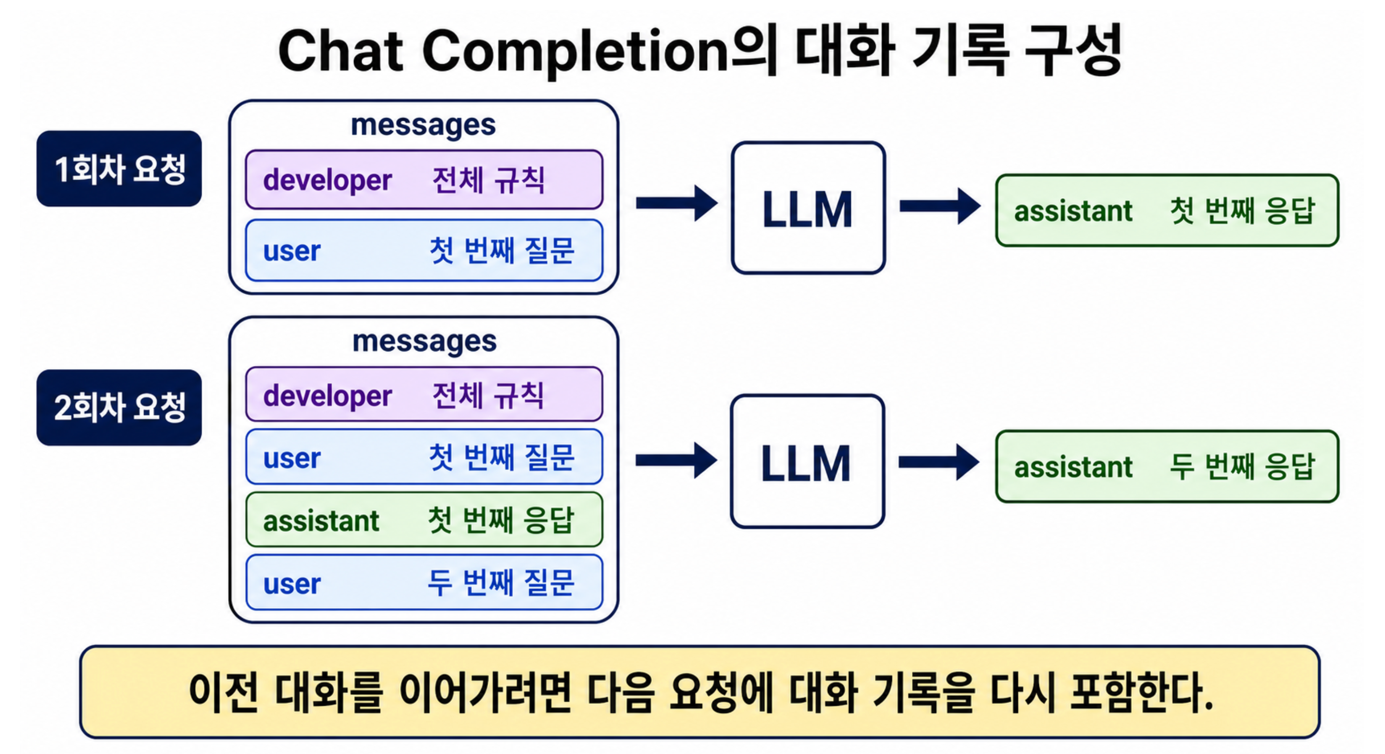

이 그림은 Chat Completions API가 한 번의 요청마다 `messages` 목록을 입력으로 받는 과정을 보여 준다. 첫 번째 요청에서는 전체 규칙을 담은 `developer` 메시지와 사용자의 질문인 `user` 메시지를 전달하고, 모델은 `assistant` 메시지를 반환한다.

두 번째 질문이 들어오면 애플리케이션은 첫 번째 요청과 응답을 포함한 대화 기록 뒤에 새로운 `user` 메시지를 추가하여 다시 전송한다. Chat Completions 요청은 서로 독립적이므로, 이전 대화를 이어가려면 과거의 `user`·`assistant` 메시지를 다음 요청의 `messages`에 포함해야 한다.

> **핵심:** 모델이 대화를 자동으로 기억하는 것이 아니라, 애플리케이션이 전달한 `messages` 기록을 바탕으로 문맥을 이어 간다.

**프롬프트 구성요소**

- **지시사항 `User Message`**: 수행하고자 하는 구체적인 작업에 대한 지시.
- **컨텍스트 `System Instruction`**: 페르소나 등의 배경정보, 외부 정보나 추가 세부사항을 제공하여 모델 응답을 보완.
- **입력 데이터**: 응답을 유도하기 위한 데이터나 질문.
- **출력 지시자**: 응답의 형식과 유형을 명시.


**Role**

| Role         | 설명                                                                                     | 사용 시점                                                                                          |
|--------------|------------------------------------------------------------------------------------------|----------------------------------------------------------------------------------------------------|
| `system`     | 대화의 초기 설정과 규칙을 정의                                                           | 대화가 시작될 때 모델의 성격, 행동, 스타일을 설정하는 메시지에서 사용                               |
| `user`       | 사용자가 모델에 요청이나 질문을 전달                                                    | 대화 중에 사용자가 요청하거나 질문할 때 사용                                                      |
| `assistant`  | 모델이 사용자에게 응답하거나 제안                                                      | 사용자의 질문에 답변하거나 함수 호출을 제안할 때 사용                                              |
| `function`   | 함수 호출을 처리하거나 함수의 반환값을 전달                                             | 모델이 함수 호출을 제안하거나 함수가 반환값을 전달할 때 사용                                       |

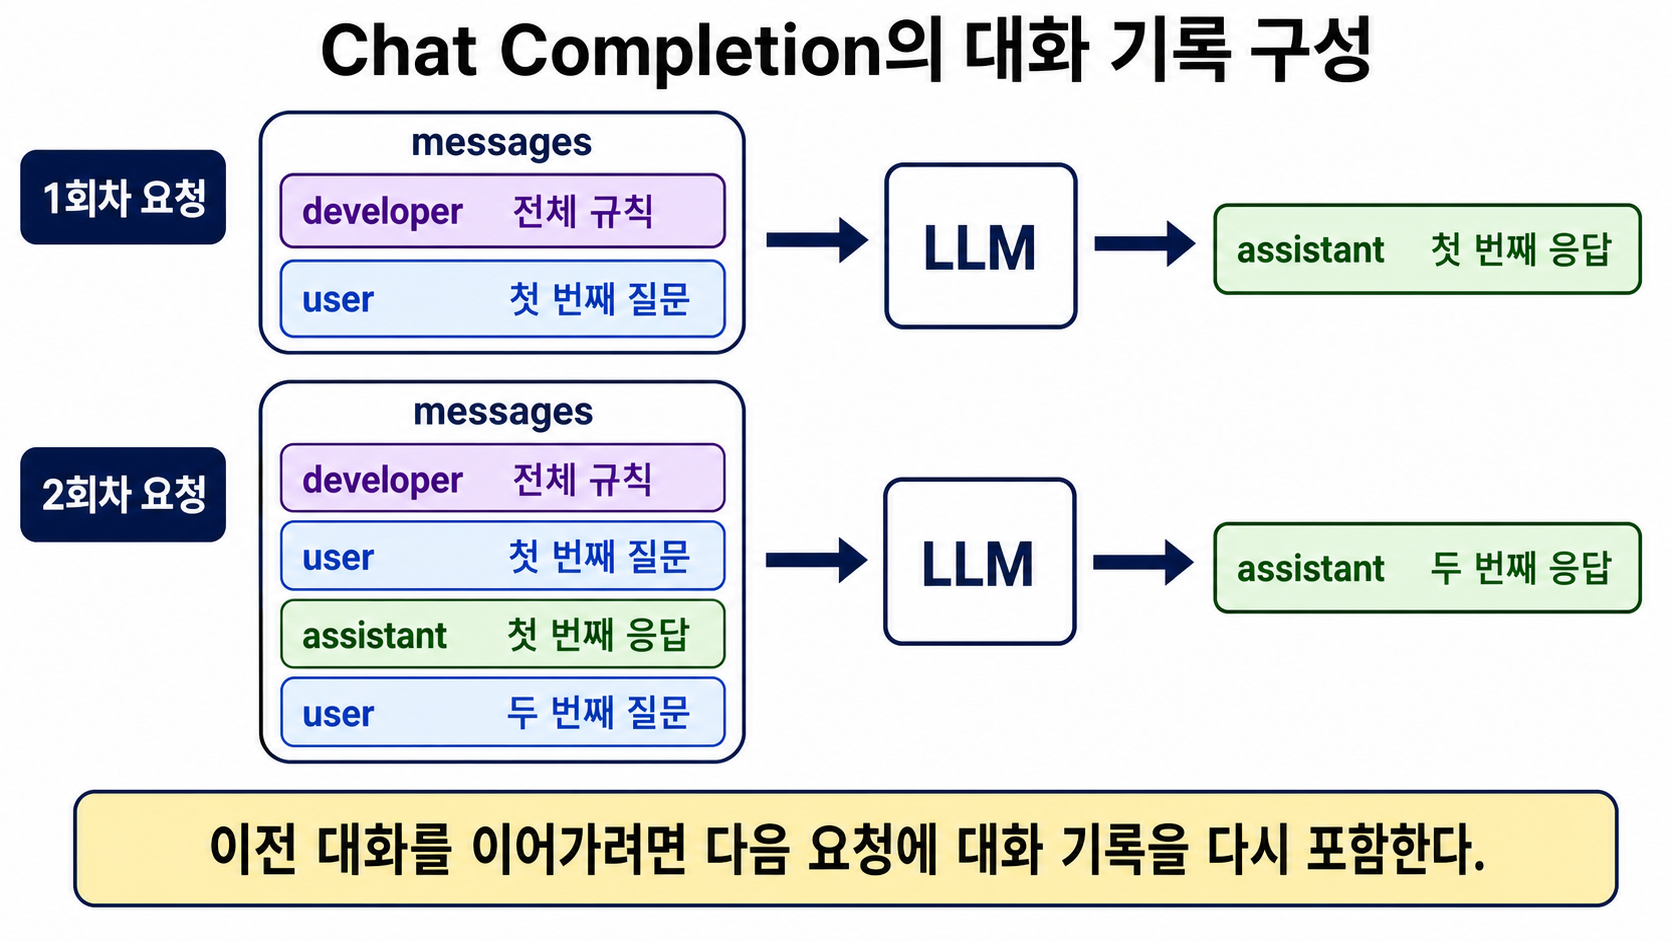

## 다양한 Prompting 기법

프롬프팅 기법은 모델의 지식을 새로 학습시키는 방법이 아니라, 이번 요청에서 모델이 과제를 이해하고 답을 구성하는 방식을 안내하는 방법이다. 간단한 과제는 짧은 지시만으로 시작하고, 결과 형식이나 판단 기준이 흔들릴 때 예시와 단계 구조를 추가한다. 기법을 많이 섞는 것보다 과제의 실패 원인에 맞는 한 가지 기법을 선택하는 것이 중요하다.

### Chat에서 실습하는 방법

1. 비교할 때는 같은 모델을 선택하고, 각 기법을 새 Chat에서 실행하여 이전 대화의 영향을 없앤다.
2. 예시 프롬프트를 그대로 입력한 뒤 결과의 정확성, 형식 준수, 일관성을 기록한다.
3. 한 번에 여러 요소를 바꾸지 않고 지시나 예시 하나만 추가하여 무엇이 결과를 바꾸었는지 확인한다.
4. Chat에서 모델을 실행하면 일반 API 요청과 같은 사용량이 발생하므로 짧은 예시부터 비교한다.


### 1. Zero-shot Prompting

Zero-shot prompting은 정답 예시를 제공하지 않고 과제 설명과 출력 규칙만으로 답을 요청하는 방법이다. 라벨의 의미가 명확한 분류, 간단한 요약, 번역처럼 모델이 이미 익숙한 과제의 기준선(baseline)을 빠르게 확인할 때 적합하다. 프롬프트가 짧아 비용이 적지만, 라벨의 경계나 원하는 형식이 모호하면 결과가 흔들릴 수 있다.

#### Chat 입력 예시

```text
다음 고객 문의를 배송, 환불, 기타 중 하나로 분류하라.

분류 기준:
- 배송: 배송 상태, 출발·도착 일정, 배송지 문의
- 환불: 주문 취소, 반품, 결제 취소 문의
- 기타: 상품 사용법, 계정, 위 범주에 속하지 않는 문의

문의: 배송 조회 화면이 사흘째 상품 준비 중인데 언제 출발하나요?
출력 형식: 분류: <배송|환불|기타>
```

결과가 `분류: 배송`처럼 요청한 형식을 지키는지 확인한다. 분류는 맞지만 설명이 덧붙는다면 출력 제약이 충분히 강하지 않았다는 뜻이다.


### 2. One-shot Prompting

One-shot prompting은 입력과 정답의 예시 한 쌍을 제공하는 방법이다. 모델이 출력 문법이나 라벨 표기 방식을 한 번만 보고도 따라야 할 때 유용하다. 다만 예시 하나가 전체 과제를 대표하지 못하면 모델이 그 사례의 표현이나 라벨에 지나치게 끌릴 수 있다.

#### Chat 입력 예시

```text
다음 고객 문의를 배송, 환불, 기타 중 하나로 분류하라.

예시:
문의: 결제한 주문을 취소하고 싶어요.
분류: 환불

이제 다음 문의를 분류하라.
문의: 배송 조회 화면이 사흘째 상품 준비 중인데 언제 출발하나요?
출력 형식: 분류: <배송|환불|기타>
```

Zero-shot 결과와 비교하여 예시가 출력 형식을 더 안정적으로 만들었는지 확인한다. 한 개의 환불 예시 때문에 모든 문제를 환불로 분류하지 않는지도 함께 점검한다.


### 3. Few-shot Prompting

Few-shot prompting은 여러 개의 입력·정답 예시를 제공하여 라벨의 경계, 문체, 출력 구조를 보여 주는 방법이다. 분류 기준이 추상적이거나 특정 형식을 반복해서 지켜야 할 때 효과적이다. 예시는 서로 모순되지 않고 실제 입력을 대표해야 하며, 예시가 지나치게 많으면 입력 토큰과 비용이 늘고 중요한 지시가 묻힐 수 있다.

#### Chat 입력 예시

```text
다음 고객 문의를 배송, 환불, 기타 중 하나로 분류하라.

예시 1:
문의: 택배가 현재 어디에 있는지 알고 싶어요.
분류: 배송

예시 2:
문의: 받은 상품을 반품하고 환불받고 싶어요.
분류: 환불

예시 3:
문의: 비밀번호를 변경하는 방법을 알려 주세요.
분류: 기타

이제 다음 문의를 분류하라.
문의: 배송 조회 화면이 사흘째 상품 준비 중인데 언제 출발하나요?
출력 형식: 분류: <배송|환불|기타>
```

세 방법의 결과가 모두 `배송`인지 비교하고, 예시가 늘어날수록 형식 준수는 좋아졌는지 확인한다. 결과가 이미 안정적이라면 긴 Few-shot 프롬프트보다 짧은 Zero-shot을 선택하는 편이 효율적이다.

> **선택 기준:** 먼저 Zero-shot으로 기준선을 확인한다. 출력 형식을 한 번 보여 주면 충분할 때 One-shot을 사용하고, 라벨 경계나 문체를 여러 사례로 보여 주어야 할 때 Few-shot을 사용한다. 예시는 실제로 관찰된 실패를 고치는 데 필요한 만큼만 제공한다.


### 4. Chain-of-Thought (CoT)

Chain-of-Thought(CoT)는 여러 계산이나 조건이 연결된 문제에서 답을 바로 요구하지 않고, 검산 가능한 핵심 단계와 근거를 함께 제시하도록 만드는 기법이다. 산술, 논리, 조건 비교처럼 중간 결과가 최종 답에 영향을 주는 과제에 적합하다. 최신 reasoning 모델에는 막연히 더 오래 생각하라고 반복하기보다 목표, 제약, 성공 기준과 필요한 출력만 명확히 주는 편이 낫다.

#### Chat 입력 예시

```text
상품 가격은 18,000원이고 3개를 구매한다. 상품 금액에만 10% 할인 쿠폰을 적용한 뒤 배송비 3,000원을 더한다.

내부 사고를 모두 나열하지 말고, 검산 가능한 계산식과 핵심 계산 단계만 간단히 제시하라.
마지막 줄은 반드시 최종 결제액: <금액>원 형식으로 작성하라.
```

상품 합계 54,000원, 할인 후 48,600원, 배송비 포함 51,600원이 서로 연결되는지 확인한다. 최종 답만 맞는 것이 아니라 표시한 계산식과 답이 일치해야 한다.


### 5. Tree-of-Thought (ToT)

Tree-of-Thought(ToT)는 하나의 풀이만 바로 선택하지 않고 여러 후보 경로를 만든 뒤 공통 기준으로 평가하여 더 나은 경로를 선택하는 접근이다. 정답이 하나로 고정되지 않은 기획, 설계, 의사결정 문제에 유용하다. Chat에서 한 번의 프롬프트로 수행하는 실습은 실제 탐색 알고리즘 전체를 구현하는 것이 아니라 후보 생성과 비교 과정을 간단히 모사하는 것이다.

#### Chat 입력 예시

```text
Python 입문자를 위한 2시간짜리 리스트와 딕셔너리 수업안을 설계하라.

후보 A: 개념 설명 후 실습
후보 B: 짧은 실습 후 개념 정리
후보 C: 미니 프로젝트 중심

각 후보를 이해도, 참여도, 시간 초과 위험의 세 기준으로 1~5점 평가하라.
평가 근거를 한 문장씩 작성하고 가장 적합한 안 하나를 선택하라.
```

세 후보가 동일한 평가 기준으로 비교되었는지와 최종 선택이 점수·근거와 일치하는지 확인한다. 후보만 많이 생성하고 선택 기준이 없으면 ToT의 장점이 사라진다.


### 6. Self-Consistency

Self-Consistency는 같은 문제를 독립적으로 여러 번 생성한 뒤 최종 답의 일치 정도를 비교하는 방법이다. 단일 정답이 있는 수학·논리 문제에서 우연한 오류를 줄이는 데 도움이 될 수 있다. 한 응답 안에서 모델에게 다섯 답을 흉내 내게 하는 것보다 같은 프롬프트를 새 Chat에서 여러 번 실행해야 독립 비교에 가깝다.

#### Chat 입력 예시

```text
어떤 수의 30%가 72이다. 그 수를 구하라.
계산식 한 줄과 최종 답만 제시하라.
```

같은 모델과 설정으로 새 Chat에서 5회 실행하고 최종 답을 기록한다. 다수 결과가 240으로 일치하는지 확인한다. 의견이나 글쓰기처럼 정답이 하나가 아닌 과제에서는 단순 다수결 대신 별도의 품질 기준이 필요하다.


### 7. Least-to-Most

Least-to-Most는 복잡한 문제를 작은 하위 문제로 나누고, 앞 단계의 답을 다음 단계의 입력으로 사용하면서 쉬운 단계부터 해결하는 기법이다. 여러 변화율이나 조건이 순서대로 적용되는 문제처럼 단계 의존성이 있을 때 적합하다. 각 단계의 입력과 출력이 명확해야 뒤 단계의 오류 원인을 찾을 수 있다.

#### Chat 입력 예시

```text
1월 매출은 12,000,000원이다. 2월 매출은 1월보다 15% 증가했고, 3월 매출은 2월보다 8% 감소했다.

1. 먼저 2월 매출을 계산하라.
2. 2월 매출을 사용하여 3월 매출을 계산하라.
3. 3월 매출이 1월보다 얼마 증가하거나 감소했는지 계산하라.
각 단계의 결과와 최종 비교를 순서대로 제시하라.
```

2월 13,800,000원, 3월 12,696,000원, 1월 대비 696,000원 증가가 순서대로 계산되는지 확인한다. 3월 계산이 최초 금액이 아니라 2월 결과를 사용하는지가 핵심이다.


### 8. Plan-and-Solve (PS)

Plan-and-Solve는 문제를 풀기 전에 필요한 공식, 작업 순서, 검증 방법을 먼저 계획하고 그 계획에 따라 실행하는 기법이다. Least-to-Most가 하위 문제의 순차적 해결에 초점을 둔다면, Plan-and-Solve는 전체 작업의 청사진과 누락 방지에 초점을 둔다. 여러 단계의 분석이나 구현 과제에서 계획과 실행이 섞여 누락되는 문제를 줄일 수 있다.

#### Chat 입력 예시

```text
2차 방정식 x^2 - 5x + 6 = 0의 해를 구하라.

1. 먼저 사용할 풀이 방법과 검산 방법을 3단계 이내로 계획하라.
2. 계획에 따라 해를 구하라.
3. 구한 해를 원래 식에 대입해 검산하라.
계획, 실행, 검산, 최종 답의 순서로 작성하라.
```

계획에서 인수분해와 대입 검산을 제시하고, 실행 단계에서 해 2와 3을 구한 뒤 두 값이 모두 원래 식을 0으로 만드는지 확인한다.


### 9. ReAct (Reasoning and Acting)

ReAct(Reasoning and Acting)는 현재 정보로 다음 행동을 결정하고, 검색·함수 호출·코드 실행 같은 도구의 관찰 결과를 받은 뒤 다음 판단을 이어 가는 방식이다. 최신 정보 확인이나 외부 시스템 조회처럼 모델의 학습 지식만으로 끝낼 수 없는 과제에 적합하다. 프롬프트에 `search(...)`라고 쓰는 것만으로 검색이 실행되는 것은 아니며, Chat에 Web search나 사용할 함수가 실제 도구로 연결되어 있어야 한다.

#### Chat 입력 예시

```text
목표: OpenAI API에서 현재 권장하는 범용 모델의 모델 ID, context window, max output을 확인하라.

규칙:
1. Web search 도구를 사용하고 developers.openai.com의 공식 문서만 근거로 사용하라.
2. 먼저 확인할 항목을 한 문장으로 정리하라.
3. 도구 실행 결과에서 모델 ID와 두 제한값을 추출하라.
4. 최종 답은 표와 공식 문서 URL로 작성하라.
5. 검색 도구를 사용할 수 없으면 추측하지 말고 확인할 수 없다고 답하라.
```

도구 호출 기록이 실제로 나타나는지, 최종 표의 값이 관찰한 공식 문서와 일치하는지 확인한다. 도구가 연결되지 않았는데 최신 값을 만들어 내면 ReAct가 아니라 근거 없는 생성이다.


> **핵심 정리:** 단순 과제는 Zero-shot부터 시작한다. 예시가 필요하면 One-shot이나 Few-shot을 추가하고, 단계 의존 문제가 있으면 CoT·Least-to-Most·Plan-and-Solve를 선택한다. 여러 후보를 비교할 때는 ToT, 반복 결과의 일치도를 볼 때는 Self-Consistency, 외부 정보나 행동이 필요할 때는 ReAct를 사용한다. 최신 reasoning 모델의 프롬프팅 지침은 [OpenAI Model guidance](https://developers.openai.com/api/docs/guides/latest-model#prompting-best-practices)에서 실행 전에 다시 확인한다.